### Cнижение размерности

#### Цель работы
Ознакомиться с основными методами понижения размерности, изучить их применение на практике, сравнить эффективность разных методов и визуализировать результаты.

#### Содержание работы. 

1. Сгенерируйте синтетический двумерный датасет с высокой степенью корреляции между признаками.
2. Понизьте размерность датасета до одной при помощи метода PCA и визуализируйте его до и после.
3. Примените метод главных компонент на более многомерных данных. Визуализируйте две главные компоненты.
4. Выберите оптимальное количество главных компонент по методу локтя.
5. Сгенерируйте двумерный датасет для классификации и примените на нём метод линейного дискриминантного анализа.
6. Сгенерируйте двумерный датасет для классификации и примените на нём метод понижения размерности t-SNE.
7. Сгенерируйте линейно неразделимый двумерный датасет для классификации и опробуйте на нём метод KernelPCA с различными ядрами.


В ходе выполнения этой работы мы познакомимся со разными методами понижения размерности. Эта задача в машинном обучении часто используется для визуализации многомерных данных, снижения объема данных, улучшения качества классификации, устранения мультиколлинеарности признаков. При этом, существуют разные методы понижения размерности, которые отличаются друг от друга не только по внутреннему устройству, но и по "техническим характеристикам", области применения, достоинствам и недостаткам. Поэтому по итогам выполнения данной работы нужно сформировать понимание того, в каких случаях какие методы следует применять.

PCA на сгенерированных данных
Самый распространенный метод понижения размерности - метод главных компонент, PCA. Для того, чтобы понять смысл и основной механизм этого метода, мы разберем его действия на нескольких примерах. Для начала - на искусственных данных. Метод главных компонент выделяет самые информативные "направления" в пространстве признаков. Проще всего увидеть это направление на таком датасете, который демонстрирует сильную корреляцию.

Сгенерируем такой набор признаков, для наглядности, двумерный:

##### PCA на сгенерированных данных
Самый распространённый метод понижения размерности — метод главных компонент, PCA. …

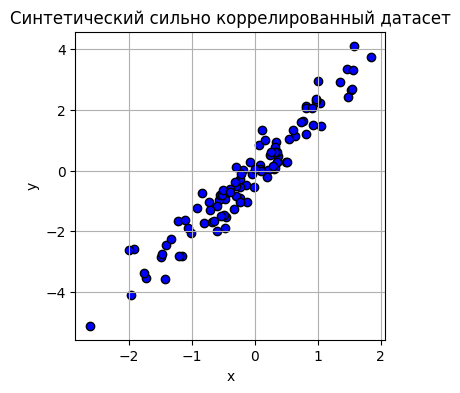

In [50]:
# импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
# генерация синтетического сильно скоррелированного двумерного датасета
n_samples = 100
x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 0.5, n_samples)
X = np.column_stack((x, y))

# визуализация исходных данных
plt.figure(figsize=(4, 4))
plt.scatter(X[:,0], X[:,1], c='blue', edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Синтетический сильно коррелированный датасет')
plt.grid(True)
plt.show()

Попробуем применить метод понижения размерности сразу, на данных как есть. Для этого импортируем класс данного метода из пакета decomposition:

In [51]:
from sklearn.decomposition import PCA

Теперь мы создаем экземпляр класса. В конструкторе класса указываем количество компонент, которые хотим оставить в данных. Так как у нас всего два измерения, придется оставлять только одно

In [58]:
X

array([[ 0.49671415,  0.28574293],
       [-0.1382643 , -0.48685126],
       [ 0.64768854,  1.12401982],
       [ 1.52302986,  2.64492108],
       [-0.23415337, -0.54894961],
       [-0.23413696, -0.26624849],
       [ 1.57921282,  4.10151858],
       [ 0.76743473,  1.62215836],
       [-0.46947439, -0.81017358],
       [ 0.54256004,  1.04789713],
       [-0.46341769, -1.88622099],
       [-0.46572975, -0.94471644],
       [ 0.24196227,  0.51403965],
       [-1.91328024, -2.59493943],
       [-1.72491783, -3.54601615],
       [-0.56228753, -0.97380139],
       [-1.01283112, -2.04301813],
       [ 0.31424733,  0.04415565],
       [-0.90802408, -1.24463674],
       [-1.4123037 , -2.44864089],
       [ 1.46564877,  3.32681351],
       [-0.2257763 , -0.90624633],
       [ 0.0675282 ,  0.83645356],
       [-1.42474819, -3.5504219 ],
       [-0.54438272, -0.7953369 ],
       [ 0.11092259,  1.31707299],
       [-1.15099358, -2.79725532],
       [ 0.37569802,  0.46824717],
       [-0.60063869,

In [60]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)
X_pca

array([[ 0.69737862],
       [-0.27582951],
       [ 1.51654798],
       [ 3.26747919],
       [-0.37379247],
       [-0.11993635],
       [ 4.6001447 ],
       [ 2.01654918],
       [-0.71192471],
       [ 1.40192556],
       [-1.67548606],
       [-0.83108819],
       [ 0.79025519],
       [-2.94998109],
       [-3.72109047],
       [-0.89970137],
       [-2.05808628],
       [ 0.40014094],
       [-1.29505971],
       [-2.59812584],
       [ 3.85452396],
       [-0.69093693],
       [ 1.00299261],
       [-3.59293711],
       [-0.73157062],
       [ 1.45365902],
       [-2.79615422],
       [ 0.8079955 ],
       [-1.07609981],
       [-0.6560858 ],
       [-1.81943027],
       [ 4.39465928],
       [-0.28493626],
       [-1.93022387],
       [ 1.64860083],
       [-1.81174253],
       [ 0.33754745],
       [-4.30422781],
       [-2.38238947],
       [ 0.10974608],
       [ 1.97551897],
       [ 1.19223408],
       [-0.7581153 ],
       [-0.36818558],
       [-2.96710581],
       [-1

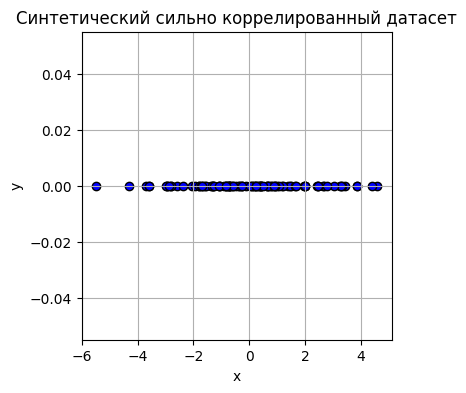

In [61]:
plt.figure(figsize=(4, 4))
plt.scatter(X_pca, [0 for i in range(len(X_pca))], c='blue', edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Синтетический сильно коррелированный датасет')
plt.grid(True)
plt.show()

Информацию о главной компоненте можно получить в соответствующих свойствах обученного объекта:

In [67]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.70710678 0.70710678]]
Объясненная дисперсия: [0.98274718]


Первое свойство хранит набор векторов главных компонент. Так как в нашем случае мы оставили только одно измерение, и главная компонента тоже будет одна. Это двумерный вектор, который и представляет собой направление в исходном пространстве.

Второй список хранит доли объясненной дисперсии по главным компонентам. Тут у нас опять только одно значение. Оно значит, что понижение размерности с двух до одного измерения сохраняет 98% исходной дисперсии выборки.

В нашем случае двумерных данных можно очень наглядно визуализировать главную компоненту в исходном распределении. Можно изобразить вектор этого направления на диаграмме рассеяния:

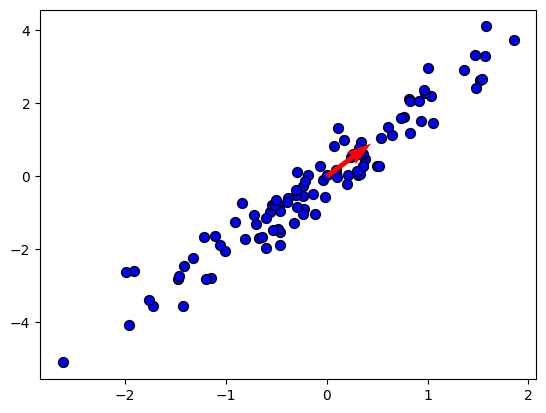

In [63]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

Попробуйте самостоятельно изменить парамеры исходного распределения и посмотреть, как это влияет на направление главной компоненты.

На практике, данные перед применение метода понижения размерности необходимо нормировать. Посмотрим, как нормировка данных влияет на результат. Воспользуемся уже известным методом стандартизации:

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Теперь воспользуемся тем же методом понижения размерности, но уже обучим его на масштабированных данных:

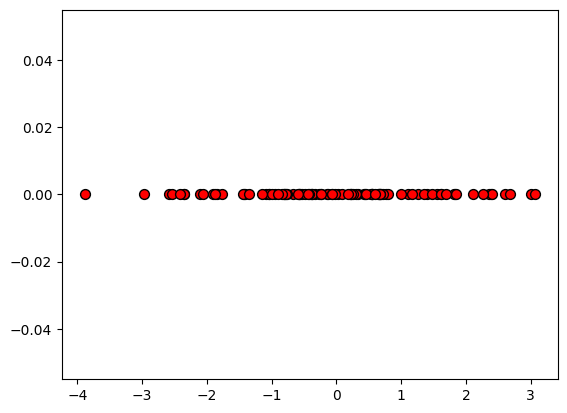

In [65]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

In [66]:
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Объясненная дисперсия: [0.98274718]


Так как решкалирование в целом сохраняет внутренние структуры, то есть расстояния между точками, это не влияет на результат понижения размерности (за исключением масштаба данных)

#### PCA на многомерных данных
по аналогии проследим работу того же алгоритма, но уже на данных, состоящих из большего количества измерений. Для примера возьмем встроенный датасет о диагностике рака:

In [78]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

In [79]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.tail(20)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
549,10.820,24.21,68.89,361.6,0.08192,0.06602,0.015480,0.00816,0.1976,0.06328,...,31.45,83.90,505.6,0.12040,0.16330,0.06194,0.03264,0.3059,0.07626,1
550,10.860,21.48,68.51,360.5,0.07431,0.04227,0.000000,0.00000,0.1661,0.05948,...,24.77,74.08,412.3,0.10010,0.07348,0.00000,0.00000,0.2458,0.06592,1
551,11.130,22.44,71.49,378.4,0.09566,0.08194,0.048240,0.02257,0.2030,0.06552,...,28.26,77.80,436.6,0.10870,0.17820,0.15640,0.06413,0.3169,0.08032,1
552,12.770,29.43,81.35,507.9,0.08276,0.04234,0.019970,0.01499,0.1539,0.05637,...,36.00,88.10,594.7,0.12340,0.10640,0.08653,0.06498,0.2407,0.06484,1
553,9.333,21.94,59.01,264.0,0.09240,0.05605,0.039960,0.01282,0.1692,0.06576,...,25.05,62.86,295.8,0.11030,0.08298,0.07993,0.02564,0.2435,0.07393,1
554,12.880,28.92,82.50,514.3,0.08123,0.05824,0.061950,0.02343,0.1566,0.05708,...,35.74,88.84,595.7,0.12270,0.16200,0.24390,0.06493,0.2372,0.07242,1
555,10.290,27.61,65.67,321.4,0.09030,0.07658,0.059990,0.02738,0.1593,0.06127,...,34.91,69.57,357.6,0.13840,0.17100,0.20000,0.09127,0.2226,0.08283,1
556,10.160,19.59,64.73,311.7,0.10030,0.07504,0.005025,0.01116,0.1791,0.06331,...,22.88,67.88,347.3,0.12650,0.12000,0.01005,0.02232,0.2262,0.06742,1
557,9.423,27.88,59.26,271.3,0.08123,0.04971,0.000000,0.00000,0.1742,0.06059,...,34.24,66.50,330.6,0.10730,0.07158,0.00000,0.00000,0.2475,0.06969,1
558,14.590,22.68,96.39,657.1,0.08473,0.13300,0.102900,0.03736,0.1454,0.06147,...,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004,1


Этот набор данных содержит 30 столбцов. Это хорошее число, имеет смысл уменьшить. Пока запомним, что в исходных данных именно 30 столбцов, это пригодится позднее.

Теперь применим метод главных компонент. Сейчас выберем уже две главные компоненты. В таком случае результат можно будет визуализировать. Обратите внимание, что мы обязательно применяем нормализацию:

In [86]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

In [81]:
X_pca.shape

(569, 2)

In [82]:
X_pca[:3,:]

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ]])

Исходный датасет мы не могли визуализировать, он тридцатимерный. Но после понижения размерности у нас получился двумерный набор данных. Его вполне можно изобразить на графике:

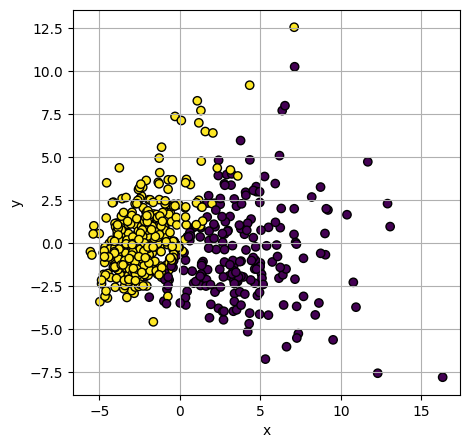

In [83]:
plt.figure(figsize=(5, 5))
plt.scatter(X_pca[:,0], X_pca[:, 1], c=y , edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

Если вы задаетесь вопросом, что именно отложено по осям, то ответ может вас разочаровать - главные компоненты. Никакого предметного смысла они не несут.

Мы здесь видим, по сути, проекцию набора точек из тридцатимерного пространства на плоскость. Причем эта плоскость расположена внутри этого тридцатимерного пространства таким образом, чтобы сохранить максимальную дисперсию. Другими словами, эта плоскость расположена так, чтобы в проекции точки были максимально разбросаны.

Можно задаться вопросом, как эта плоскость расположена внутри этого тридцатимерного пространства. Плоскость задается двумя векторами. Именно эти вектора и есть главные компоненты - направления, вдоль которых дисперсия максимальна.

In [84]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Конечно, два тридцатимерных вектора не очень информативны.

В отличие от предыдущего примера, мы все-таки очень сильно сократили размерность. Это значит, что точки все равно сильно сместились относительно своего изначального положения в проекцию. То есть часть данных мы потеряли. Давайте посмотрим, какую именно часть выборочной дисперсии мы сохранили после понижения размерности:

In [87]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163]
Суммарная объясненная дисперсия: 0.73


В соответствующем свойстве объекта модели лежит массив, который показывает долю сохраненной (объясненной) дисперсии данных по каждой компоненте. Здесь мы видим, что проекция на первую главную компоненту сохраняет 44% дисперсии исходных данных. Это значит, что если бы мы сократили размерность до одной, то потеряли бы 56% исходной информации.

Введение второй компоненты добавляет еще 19% дисперсии. Таким образом, всего у нас получается 63%. Можно считать, что понижение размерности в данном случае приводит к потере 37% информации о разбросе точек, имеющейся в исходном наборе.

#### Метод локтя для PCA
Метод понижения размерности полезен для визуализации данных, но применяют его не только для этого. Он может быть хорошим помощником в тех случаях, когда в исходных данных слишком много признаков, их число надо сократить, но так, чтобы максимально сохранить имеющуюся информацию. В таком случае встает вопрос выбора количества компонент.

При определении оптимального количества компонент следует ориентироваться на то, насколько быстро растет количество информации в зависимости от количества измерений. Для того, чтобы отследить эту зависимость, построим график. Для этого построим алгоритм главных компонент с количеством компонент от 1 до 30:

In [88]:
n_components_range = range(1, 31)
explained_variance = []

Для каждого количества обучим и оценим соответствующую модель и запомним процент объясненной дисперсии:

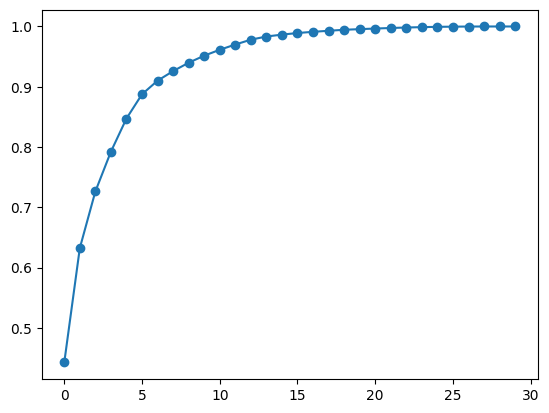

In [89]:
n_components_range = range(1, 31)
explained_variance = []

for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.plot(range(len(n_components_range)), explained_variance, 'o-')

Единственная главная компонента обеспечивает 44% вариации исходных данных (мы уже видели это число ранее). При добавлении второй - мы получаем значительную прибавку. При добавлении третьей - прибавка чуть меньше. С каждой новой компонентой мы получаем чуть меньше дополнительной информации.

Смысл в том, чтобы найти такое количество, которое дает оптимальное количество сохраненной информации. Для этого найдем такое значение, в котором данная кривая максимально изгибается. Это и будет локоть. Можно предположить, что в данном случае оптимальное количество 6 или 7 компонент. Если брать больше, дополнительные измерения уже не обеспечат такого значительного прироста информации.

In [90]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


При выводе массива значений объясненной дисперсии мы видим два уже знакомых нам значения, а числа дальше показывают, сколько дополнительной объясненной дисперсии прибавляет каждая следующая главная компонента:

Обратите внимание, что в данном методе первые компоненты не зависят от того, сколько компонент мы задала. Другими словами, метод всегда найдет одну и ту же главную компоненту, ее положение не зависит от количества компонент, которые мы оставляем. То есть, задание количества компонент по сути является лишь критерием остановки алгоритма (как ограничение глубины решающего дерева).

Именно поэтому если мы построим две первые главные компоненты этой семимерной модели, они будут полностью идентичны предыдущей модели:

#### Метод LDA

Метод главных компонент неплохо работает в большинстве случаев. Однако, у него есть один недостаток - он принимает во внимание только взаимное расположение точек. Если перед вами датасет для классификации, этот метод может найти такие компоненты, то есть такие направления в исходном пространстве, после проекции на которые, точки разных классов могут оказаться еще ближе друг к другу, чем были в исходном распределении. Это может сильно осложнить задачу классификации, когда после проекции точки классов перемешаются.

Именно для решения этой проблемы существует метод линейного дискриминантного анализа. Он принимает во внимание значение целевой переменной. И выбирает направления проекции таким образом, чтобы максимизировать расстояние между классами. Рассмотрим, например, такой датасет:

In [91]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

Это двумерный набор искусственных данных для классификации. Вот как он выглядит вместе с информацией о классах:

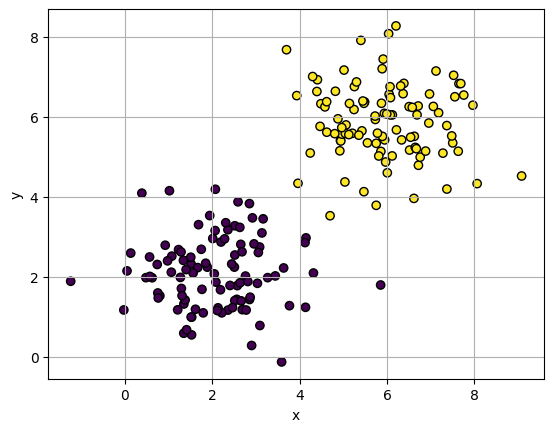

In [92]:
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

Легко представить себе, что проецируя это распределение вдоль некоторых направлений, изначально очень разделимые классы могут полностью перемешаться. Посмотрим, как этому препятствует метод LDA. Интерфейс у класса этого метода, конечно, точно такой же, как и у предыдущего:

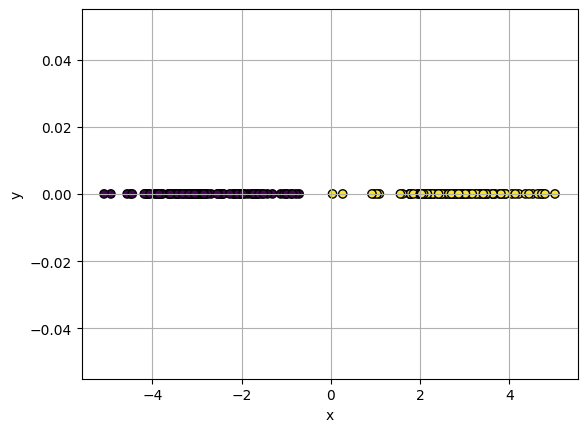

In [97]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.scatter(X_lda, y=[0 for i in range(len(X_lda))], c =y, edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

Как и в предыдущем методе, мы можем найти информацию о направлении проекции в исходном пространстве. Для этого в методе LDA есть свойство intercept

In [98]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[ 7.85164749 10.06908117]]


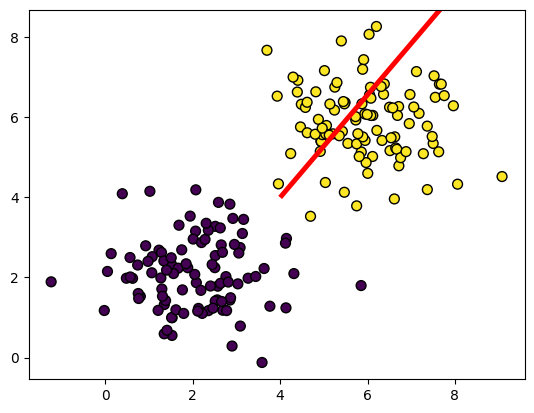

In [99]:
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(4, 4, lda.coef_[0,0], lda.coef_[0,1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

#### Метод t-SNE

Рассмотрим еще один интересный метод понижения размерности - t-SNE. Он часто используется для визуализации кластеров - то есть близких групп точек в наборе данных. Давайте рассмотрим механизм его действия на примере уже использованного нами датасета для классификации:

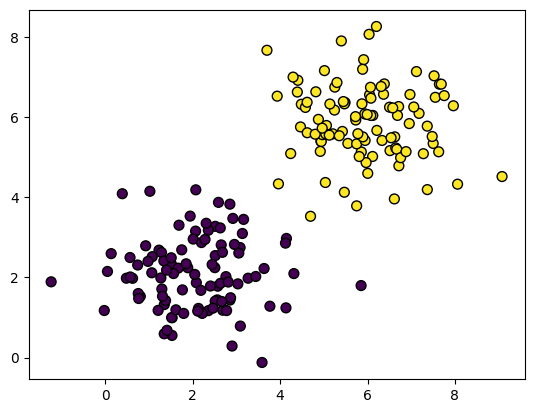

In [100]:
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=50)

Для обучения метода, как всегда импортируем соответствующий класс. Его интерфейс не отличается от других классов, реализующих алгоритмы обучения без учителя:

In [102]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

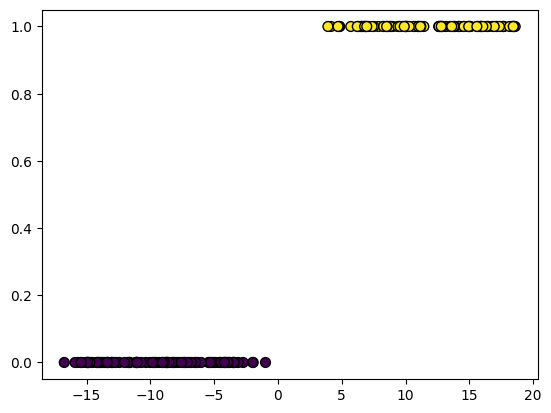

In [103]:
plt.scatter(X_tsne, y, c=y, edgecolor='k', s=50)

Результат существенно отличается от того, что мы видели в PCA

Однако, имейте в виду, что данному алгоритму нигде не передавались метки классов, то есть значение целевой переменной. Алгоритм выделил эти группы точек самостоятельно, ориентируясь исключительно на их схожесть.

Алгоритм t-SNE является параметрическим. У него есть один главный гиперпараметр, который существенно влияет на работу алгоритма. Это так называемый perplexity - он влиет на то, какие структуры будут превалировать в анализе, крупномасштабные или мелкие.

Теоретически очень сложно прочувствовать влияние этого параметр на суть работы алгоритма. Поэтому мы попробуем разные значения на практике. Авторы алгоритма рекомендуют в качестве рабочего диапазона значений этого параметра разброс от 5 до 50. Попробуем несколько конкретных значений из этого диапазона:

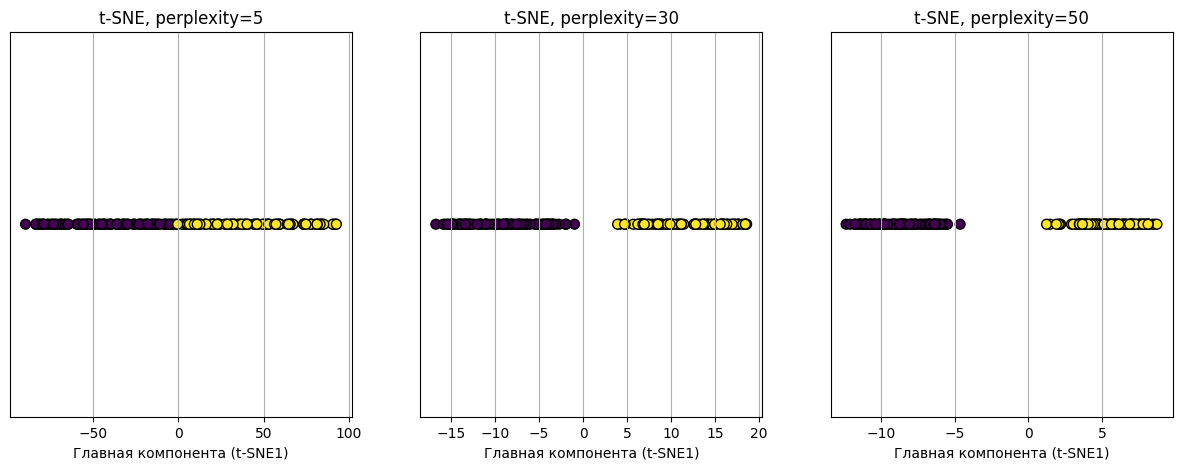

In [104]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)
    

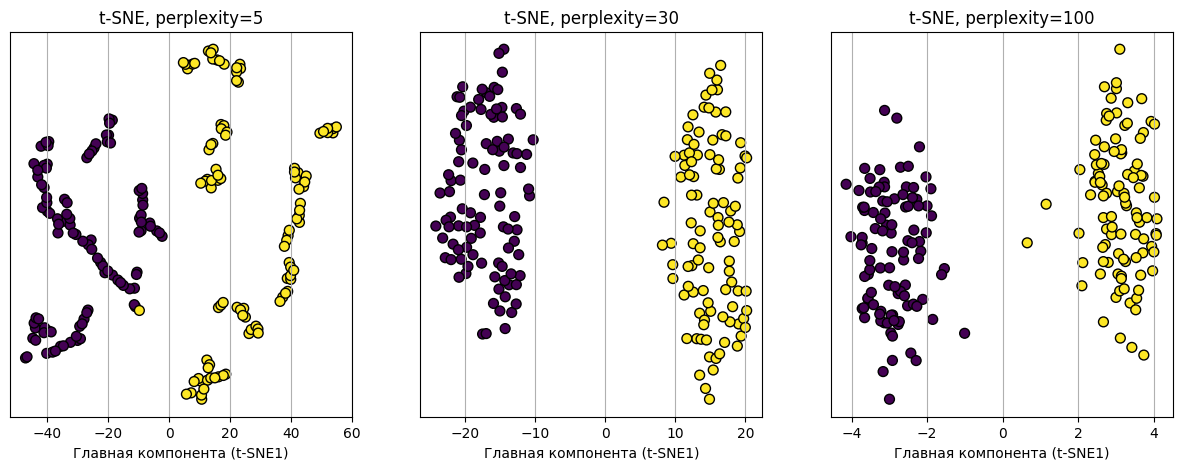

In [107]:
perplexity_values = [5, 30, 100]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)
    

#### Kernel PCA для нелинейных данных

Из рассмотренных выше моделей только t-SNE является нелинейным. Два предыдущие методы осуществляют только линейные преобразования исходного пространства. Однако, для некоторых методов возможно применение трюка с ядерными функциями, то есть введение нелинейного преобразования.

Давайте посмотрим датасет с линейно неразделимыми классами:

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolor='k', s=50)

- Ядерные функции работают в методе главных компонент примерно также, как и в методе опорных векторов. И ядерные функции используются такие же. Мы попробуем три самые распространенные:
- kernels = ['linear', 'poly', 'rbf']
- Теперь для каждой функции ядра обучим соответствующий алгоритм и визуализируем результаты. Для разнообразия мы "понизим" размерность с двух до двух. Сейчас это имеет смысл, так как имеет место сложное нелинейное преобразование, так что после него мы явно увидим действие той или иной ядерной функции:

In [ ]:
X.shape

In [ ]:
from sklearn.decomposition import KernelPCA
for kernel in ['linear', 'poly', 'rbf']:
    kpca = KernelPCA(n_components=1, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X)
    plt.scatter(X_kpca[:,0], y=y, c=y, cmap='viridis', edgecolor='k', s=50)

    plt.show()

In [ ]:
X_kpca[:,0].shape, y.shape

In [ ]:
X_kpca